# Manejo de máscaras como función identidad

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

def exponencial(x, theta):
    return theta * np.exp(- theta * x) * (x > 0)


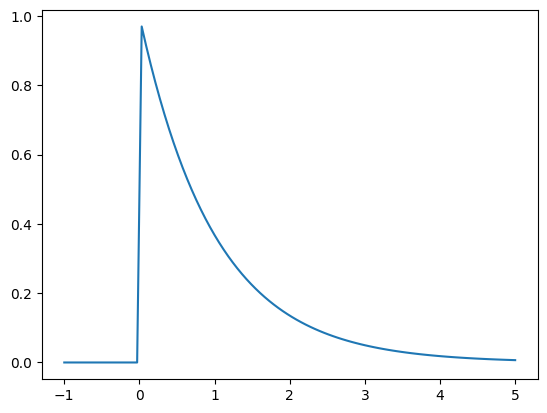

In [2]:
x = np.linspace(-1, 5, 100)
plt.plot(x, exponencial(x, 1)) 

# Ejercicio 5

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal

# Datos de la Clase w1
w1_data = np.array([
    [ 0.42,   -0.087,  0.58 ],
    [-0.2,    -3.3,   -3.4  ],
    [ 1.3,    -0.32,   1.7  ],
    [ 0.39,    0.71,   0.23 ],
    [-1.6,    -5.3,   -0.15 ],
    [-0.029,   0.89,  -4.7  ],
    [-0.23,    1.9,    2.2  ],
    [ 0.27,   -0.3,   -0.87 ],
    [-1.9,     0.76,  -2.1  ],
    [ 0.87,   -1.0,   -2.6  ]
])

# Datos de la Clase w2
w2_data = np.array([
    [-0.4,     0.58,   0.089 ],
    [-0.31,    0.27,  -0.04  ],
    [ 0.38,    0.055, -0.035 ],
    [-0.15,    0.53,   0.011 ],
    [-0.35,    0.47,   0.034 ],
    [ 0.17,    0.69,   0.1   ],
    [-0.011,   0.55,  -0.18  ],
    [-0.27,    0.61,   0.12  ],
    [-0.065,   0.49,   0.0012],
    [-0.12,    0.054, -0.063 ]
])

# Datos de la Clase w3
w3_data = np.array([
    [ 0.83,    1.6,   -0.014 ],
    [ 1.1,     1.6,    0.48  ],
    [-0.44,   -0.41,   0.32  ],
    [ 0.047,  -0.45,   1.4   ],
    [ 0.28,    0.35,   3.1   ],
    [-0.39,   -0.48,   0.11  ],
    [ 0.34,   -0.079,  0.14  ],
    [-0.3,    -0.22,   2.2   ],
    [ 1.1,     1.2,   -0.46  ],
    [ 0.18,   -0.11,  -0.49  ]
])

# Parámetros reales para la Clase 1
mu1_true = np.mean(w1_data, axis=0)
cov1_true = np.cov(w1_data, rowvar=False)

# Parámetros reales para la Clase 2
mu2_true = np.mean(w2_data, axis=0)
cov2_true = np.cov(w2_data, rowvar=False)

def entrenar_dicotomizador_mle(X):
    """Estima la media y la matriz de covarianza por Máxima Verosimilitud."""
    mu_est = np.mean(X, axis=0)
    # rowvar=False indica que las columnas son las variables
    cov_est = np.cov(X, rowvar=False) 
    
    # Si es 1D, np.cov devuelve un escalar, lo convertimos a array 1x1
    if cov_est.ndim == 0:
        cov_est = np.array([[cov_est]])
    return mu_est, cov_est

def integrar_error_numericamente(mu1, cov1, mu2, cov2, dimensiones, bins=50):
    """
    Realiza una integración numérica sobre una grilla para estimar la tasa de error.
    El error es la integral del mínimo entre P(w1)p(x|w1) y P(w2)p(x|w2).
    """
    # Definimos los límites de integración (rango de la grilla)
    # Tomamos +/- 4 desviaciones estándar desde las medias para abarcar casi toda la campana
    bounds = []
    for d in range(dimensiones):
        min_val = min(mu1[d] - 4*np.sqrt(cov1[d,d]), mu2[d] - 4*np.sqrt(cov2[d,d]))
        max_val = max(mu1[d] + 4*np.sqrt(cov1[d,d]), mu2[d] + 4*np.sqrt(cov2[d,d]))
        bounds.append((min_val, max_val))

    # Creamos la grilla N-dimensional
    axes = [np.linspace(b[0], b[1], bins) for b in bounds]
    grid = np.meshgrid(*axes, indexing='ij')
    points = np.vstack([g.ravel() for g in grid]).T

    # Evaluamos las funciones de densidad de probabilidad (PDFs)
    rv1 = multivariate_normal(mean=mu1[:dimensiones], cov=cov1[:dimensiones, :dimensiones])
    rv2 = multivariate_normal(mean=mu2[:dimensiones], cov=cov2[:dimensiones, :dimensiones])

    pdf1_ponderada = rv1.pdf(points) * 0.5
    pdf2_ponderada = rv2.pdf(points) * 0.5

    # La probabilidad de error en cada punto es el valor mínimo entre ambas curvas/superficies
    min_pdf = np.minimum(pdf1_ponderada, pdf2_ponderada)

    # Calculamos el diferencial de volumen (dx * dy * dz ...)
    dv = np.prod([(b[1] - b[0]) / bins for b in bounds])

    # Aproximación de la integral (Suma de Riemann)
    error_integral = np.sum(min_pdf) * dv
    return error_integral

for dim in [1, 2, 3]:
    print(integrar_error_numericamente(mu1_true, cov1_true, mu2_true, cov2_true, dim))
    

0.20029658759633898
0.04984800841166028
0.004490191966305646
